In [9]:
import os
import random

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from core.data import load_dataset, split_dataset, BreathDataset, CLASSES, CLASS_TO_IDX
from models.pinn import BreathMLP

plt.rcParams.update({'legend.fontsize': 9,
                     'axes.titlesize': 10})

In [18]:
# params
REGION = 'mouth'
SEED = 42
T_MAX = 70.0
N_TIMESTEPS = 36
CKPT = f'results/mlp/{REGION}_s{SEED}'
CHANNEL_NAMES = ['Humidity (norm.)', 'Temperature (norm.)']

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [15]:
# load data
df = load_dataset('dataset')
df = df[df['region'] == REGION].reset_index(drop=True)
df_train, df_val, df_test = split_dataset(df, random_state=SEED)
train_ds = BreathDataset(df_train)
val_ds   = BreathDataset(df_val, stats=train_ds.stats)
test_ds  = BreathDataset(df_test, stats=train_ds.stats)

t_norm = torch.linspace(0, T_MAX, N_TIMESTEPS) / T_MAX

print(f'train: {len(train_ds)} val: {len(val_ds)} test: {len(test_ds)}')

# load models
fitted: list[tuple[BreathMLP, int, int]] = []

for i in range(len(train_ds)):
    ckpt = os.path.join(CKPT, f'sample_{i}.pt')
    _, _, label, _ = train_ds[i]
    model = BreathMLP()
    model.load_state_dict(torch.load(ckpt, map_location='cpu', weights_only=True))
    model.eval()
    fitted.append((model, label, i))

print(f'Loaded {len(fitted)} models from {CKPT}')

train: 215 val: 28 test: 28
Loaded 215 models from results/mlp/mouth_s42


Mean MSE Summary:
Combined (H+T)	: 0.00099
Humidity	: 0.00101
Temperature	: 0.00097
bradypnea   	: 0.00207 (n=71)
eupnea      	: 0.00054 (n=68)
tachypnea   	: 0.00039 (n=76)
Stage 1 reconstruction: 215/215 samples pass threshold (MSE < 1.0)


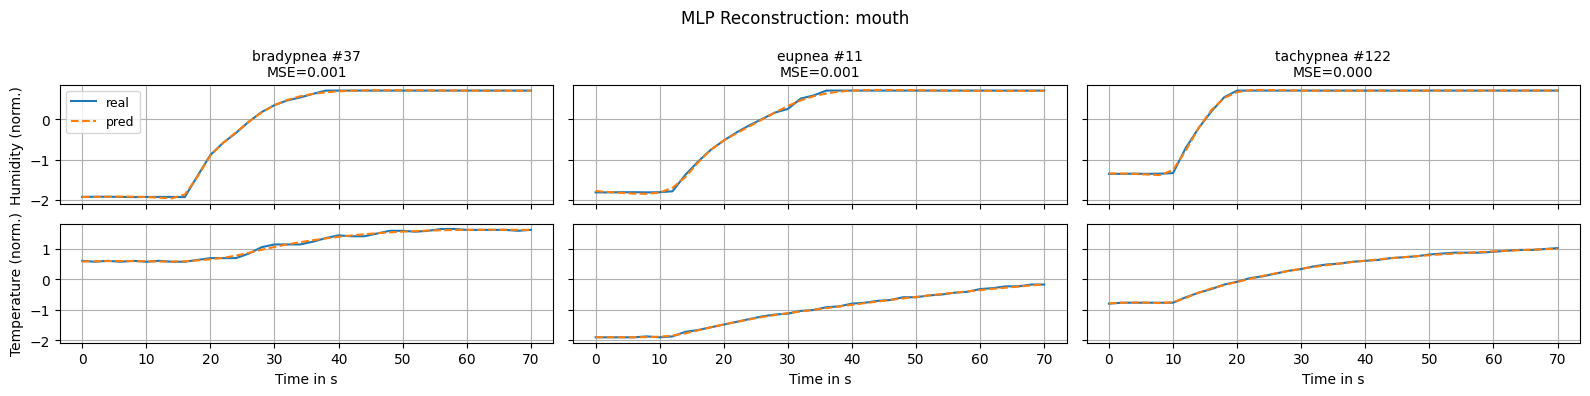

In [36]:
# summary
hum_mse, tmp_mse, comb_mse = [], [], []
per_class: dict[str, list[float]] = {cls: [] for cls in CLASSES}

for model, label, sample_i in fitted:
    signal, _, _, _ = train_ds[sample_i]
    with torch.no_grad():
        y_pred = model(t_norm, label)
    y_obs = signal.T
    h = nn.functional.mse_loss(y_pred[:, 0], y_obs[:, 0]).item()
    t = nn.functional.mse_loss(y_pred[:, 1], y_obs[:, 1]).item()
    c = nn.functional.mse_loss(y_pred, y_obs).item()
    hum_mse.append(h)
    tmp_mse.append(t)
    comb_mse.append(c)
    per_class[CLASSES[label]].append(c)

comb_mse = np.array(comb_mse)

print(f'{'Mean MSE Summary:'}')
print(f'Combined (H+T)\t: {np.mean(comb_mse):.5f}')
print(f'Humidity\t: {np.mean(hum_mse):.5f}')
print(f'Temperature\t: {np.mean(tmp_mse):.5f}')
for cls in CLASSES:
    vals = per_class[cls]
    print(f'{cls:<12}\t: {np.mean(vals):.5f} (n={len(vals)})')

n_pass = int((comb_mse < 1.0).sum())
N = len(comb_mse)
print(f'Stage 1 reconstruction: {n_pass}/{N} samples pass threshold (MSE < 1.0)')

# plot
rng = random.Random(SEED)
selected_samples: list = []
selected_models:  list = []

for cls in CLASSES:
    cls_idx = CLASS_TO_IDX[cls]
    pool = [i for i, (_, lbl, _) in enumerate(fitted) if lbl == cls_idx]

    if not pool:
        continue
    fi = rng.choice(pool)
    model, lbl, sample_i = fitted[fi]
    signal, _, _, _ = train_ds[sample_i]

    selected_samples.append((signal, lbl, sample_i))
    selected_models.append(model)

t_plot = torch.linspace(0, T_MAX, N_TIMESTEPS).numpy()

fig, axes = plt.subplots(2, 3, figsize=(16, 4), sharex=True, sharey='row')
fig.suptitle(f'MLP Reconstruction: {REGION}')

for col, ((signal, label, idx), model) in enumerate(zip(selected_samples[:3], selected_models[:3])):
    with torch.no_grad():
        y_pred = model(t_norm, label).numpy()

    y_obs = signal.T.numpy()
    mse_row = float(np.mean((y_pred - y_obs) ** 2))

    for ch in range(2):
        ax = axes[ch, col]
        ax.plot(t_plot, y_obs[:, ch], '-', color='tab:blue', lw=1.5, label='real')
        ax.plot(t_plot, y_pred[:, ch], '--', color='tab:orange', lw=1.5, label='pred')
        ax.grid()
        if ch == 0:
            ax.set_title(f'{CLASSES[label]} #{idx}\nMSE={mse_row:.3f}')
        if col == 0:
            ax.set_ylabel(CHANNEL_NAMES[ch])
        if ch == 1:
            ax.set_xlabel('Time in s')
        ax.tick_params()
        if ch == 0 and col == 0:
            ax.legend(loc='upper left')

plt.tight_layout()
plt.show()